In [25]:
from PINN_validation import *
device='cpu'

In [26]:
from OLD.glc_surrogate_torch_alg import glc_surrogate_dx_torch_nostuck_alg
model_path = "Training/PINN.pth"
model = rebuild_pinn_from_weights(model_path, device=device)

# ---- Choose sweep ranges here ----
# Example: full normalized training range (you can change to any range you want)
u1_min, u1_max = 0.05, 1.0
u2_min, u2_max = 0.10, 1.0

U1, U2, Y = sweep_pinn(
    model,
    u1_min=u1_min,
    u1_max=u1_max,
    u2_min=u2_min,
    u2_max=u2_max,
    n_u1=101,
    n_u2=101,
    device=device,
    batch_size=16384,
)
print(Y.shape)


=== LOADING STATE_DICT FROM Training/PINN.pth ===
Rebuilt PINN: n_u=2, n_y=3, hidden_units=[64, 64, 64]
(101, 101, 3)


In [27]:
@torch.no_grad()
def eval_f_on_grid(U1, U2, Y, device="cpu", batch_size=16384):
    """
    U1, U2: (n_u2, n_u1) meshgrids
    Y:      (n_u2, n_u1, 3) PINN states
    returns WOO: (n_u2, n_u1) w_o_out from f
    """
    n_u2, n_u1 = U1.shape

    # flatten grid -> (N,2)
    U_flat = np.stack([U1.reshape(-1), U2.reshape(-1)], axis=1).astype(np.float32)
    U_t = torch.from_numpy(U_flat).to(device)

    # flatten states -> (N,3)
    Y_flat = Y.reshape(-1, Y.shape[-1]).astype(np.float32)
    Y_t = torch.from_numpy(Y_flat).to(device)

    w_list = []
    for k in range(0, U_t.shape[0], batch_size):
        ub = U_t[k:k+batch_size]
        yb = Y_t[k:k+batch_size]

        out = glc_surrogate_dx_torch_nostuck_alg(yb, ub)  # (B,3): [w_o_out, P_bh_bar, P_tb_b_bar]
        w_list.append(out[:, 0].detach().cpu())          # keep only w_o_out

    WOO = torch.cat(w_list, dim=0).numpy().reshape(n_u2, n_u1)
    return WOO

In [28]:
import matplotlib.pyplot as plt

In [29]:
def plot_surface(U1, U2, Z, zlabel="w_o_out", title="w_o_out(u1,u2)", save_path=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(U1, U2, Z, linewidth=0, antialiased=True)
    ax.set_xlabel("u1")
    ax.set_ylabel("u2")
    ax.set_zlabel(zlabel)
    ax.set_title(title)

    # optional: make (u1=1,u2=1) the closest vertex
    # ax.set_xlim(U1.max(), U1.min())
    ax.set_ylim(U2.max(), U2.min())
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200)
        print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)

Saved: Training/f_w_o_out.png


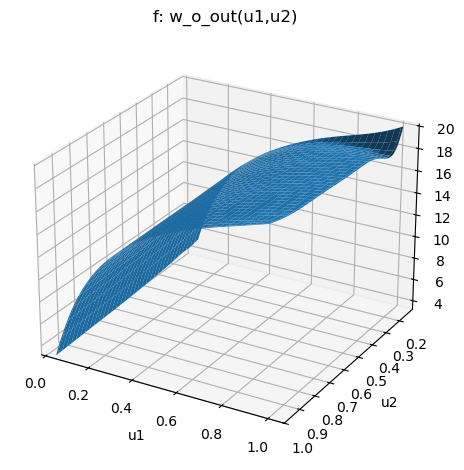

In [30]:
WOO = eval_f_on_grid(U1, U2, Y, device=device, batch_size=16384)
plot_surface(U1, U2, WOO, zlabel="w_o_out", title="f: w_o_out(u1,u2)", save_path="Training/f_w_o_out.png")

In [31]:
y_min = Y.min(axis=(0,1))
y_max = Y.max(axis=(0,1))

print("Y min:", y_min)
print("Y max:", y_max)

Y min: [3046.238   224.8987 6405.347 ]
Y max: [ 4786.7383  1085.065  11858.038 ]
